# The 90-degree optical hybrid, blind phase retrieval, and Mie scattering

Three ways to recover phase from the SAME hidden field, now including a
piece of REAL hardware (not just algorithms): the 90-degree optical hybrid
(`projects/vpi_hybrid90deg/hybrid_90deg.py`, fixed this session against
VPIphotonics' documented equation) is the actual, standard coherent-receiver
component -- it mixes an unknown signal against a KNOWN local oscillator
(LO) to directly recover amplitude and phase. That is exactly the kind of
hardware this repo's founding project brief wanted to AVOID needing (a
"carrier-less" receiver, phase from intensity alone, no LO). Comparing it
against blind 2-/3-plane GS and spectral interferometry -- on the identical
SEALS Mie-scattered field used in `phase_retrieval_connections.ipynb` and
`five_lenses_one_seals_problem.ipynb` -- makes that tradeoff concrete
instead of asserted.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'projects' / 'vpi_hybrid90deg'))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from dgs import gs_core
from dgs.spectral_interferometry import spectral_interferogram, valid_tau_range, hilbert_demodulate
from projects.seals.inverse import seals_to_tdgsa as bridge
from hybrid_90deg import hybrid_90deg
print("loaded gs_core, spectral_interferometry, seals_to_tdgsa, hybrid_90deg")

loaded gs_core, spectral_interferometry, seals_to_tdgsa, hybrid_90deg


## Part 1 -- the same Mie field, blind GS and spectral interferometry (recap)

Reused directly from earlier sessions' work, not recomputed differently.

In [2]:
demo_2plane = bridge.run_bridge_demo(D1=6000.0, D2=-7000.0, n_iter=150)
demo_3plane = bridge.run_multiplane_bridge_demo(Ds=(6000.0, -7000.0, 12000.0), n_iter=150)

E_p = demo_2plane['mie_fields'].E_p
E_p_norm = E_p / np.abs(E_p).max()
n_p = len(E_p)
omega_p = np.linspace(-1.0, 1.0, n_p)
tau_min_p, tau_max_p = valid_tau_range(omega_p)
tau_p = (tau_min_p + tau_max_p) / 2.0
E_ref_p = np.ones(n_p, dtype=complex)
S_p = spectral_interferogram(E_p_norm, E_ref_p, omega_p, tau_p)
result_si = hilbert_demodulate(S_p, omega_p, tau_p, E_ref=E_ref_p)
phi_true_p = np.angle(E_p)
phi_si = result_si['phase_est']
offset_si = np.angle(np.mean(np.exp(1j * (phi_true_p - phi_si))))
aligned_si = np.angle(np.exp(1j * (phi_si + offset_si - phi_true_p)))
rms_si = float(np.sqrt(np.mean(aligned_si ** 2)))

print(f"2-plane blind GS   RMS vs truth: {demo_2plane['rms_gs_vs_truth']:.4f} rad")
print(f"3-plane blind GS   RMS vs truth: {demo_3plane['rms_vs_truth']:.6f} rad")
print(f"spectral interferometry RMS vs truth: {rms_si:.4f} rad")

2-plane blind GS   RMS vs truth: 0.5044 rad
3-plane blind GS   RMS vs truth: 0.001420 rad
spectral interferometry RMS vs truth: 0.0577 rad


## Part 2 -- the 90-degree hybrid: real hardware, known LO

Feed the SAME Mie field (normalized, matching the spectral-interferometry
treatment) into the 90-degree hybrid as `signalInput1`, against a KNOWN,
constant local oscillator (`signalInput2=1`, matching spectral
interferometry's `E_ref=1` choice above -- an apples-to-apples reference
field, not a different assumption per method). Demodulate the way a real
receiver actually would: through BALANCED PHOTODETECTORS (intensity
measurements, `|E|^2`, at each of the 4 ports, then electronic
subtraction) -- not by reading the complex field outputs directly, which
no real detector can do.

**First, with VPI's formula exactly as printed** (`row4_lo_sign=+1.0`) --
this is what the module docstring documents as bug 4: rows 3 and 4 are
identical at this ideal operating point (zero loss, zero imbalance), so Q
should come out identically zero.

In [3]:
E_LO = 1.0 + 0j

def demodulate(row4_lo_sign):
    I_signal = np.zeros(n_p)
    Q_signal = np.zeros(n_p)
    for i in range(n_p):
        outputs = hybrid_90deg(E_p_norm[i], E_LO, row4_lo_sign=row4_lo_sign)
        I_signal[i] = abs(outputs['signalOutput0grad'])**2 - abs(outputs['signalOutput180grad'])**2
        Q_signal[i] = abs(outputs['signalOutput90grad'])**2 - abs(outputs['signalOutput270grad'])**2
    phi_est = np.arctan2(Q_signal, I_signal)
    offset = np.angle(np.mean(np.exp(1j * (phi_true_p - phi_est))))
    aligned = np.angle(np.exp(1j * (phi_est + offset - phi_true_p)))
    rms = float(np.sqrt(np.mean(aligned ** 2)))
    return I_signal, Q_signal, rms

I_printed, Q_printed, rms_printed = demodulate(row4_lo_sign=1.0)
print(f"VPI's formula AS PRINTED: Q identically zero? {np.allclose(Q_printed, 0.0)}")
print(f"RMS vs truth: {rms_printed:.4f} rad  (no better than an uninformed guess -- the receiver is non-functional)")

VPI's formula AS PRINTED: Q identically zero? True
RMS vs truth: 0.9440 rad  (no better than an uninformed guess -- the receiver is non-functional)


**The fix**, found by testing the natural hypothesis (row 4's LO term
should flip sign, mirroring how row 2 is the sign-flipped partner of row
1 -- matching standard quadrature-receiver theory, where all four ports
must be genuinely distinct):

In [4]:
I_hybrid, Q_hybrid, rms_hybrid = demodulate(row4_lo_sign=-1.0)  # the module's default
print(f"CORRECTED sign: Q identically zero? {np.allclose(Q_hybrid, 0.0)}")
print(f"Q std: {Q_hybrid.std():.4e}")
print(f"RMS vs truth: {rms_hybrid:.6f} rad")
print(f"\nimprovement: {rms_printed:.4f} rad (broken) -> {rms_hybrid:.6f} rad (corrected)")
print("A known, perfect LO SHOULD give near-exact phase recovery -- exactly what the")
print("corrected sign produces, and exactly what standard coherent-receiver theory predicts.")

CORRECTED sign: Q identically zero? False
Q std: 2.6209e-01
RMS vs truth: 0.000000 rad

improvement: 0.9440 rad (broken) -> 0.000000 rad (corrected)
A known, perfect LO SHOULD give near-exact phase recovery -- exactly what the
corrected sign produces, and exactly what standard coherent-receiver theory predicts.


## Part 3 -- three-way (now four-way) honest comparison

Same caveat as the earlier connections notebooks: different methods, different
hardware assumptions, not a ranking to declare one "best" in the abstract.

,method,needs_LO,rms_vs_truth_rad
0,2-plane blind GS,False,5.044411e-01
1,3-plane blind GS,False,1.420107e-03
2,spectral interferometry,reference arm,5.766628e-02
3,90-degree hybrid (balanced PD),True,6.306782e-16


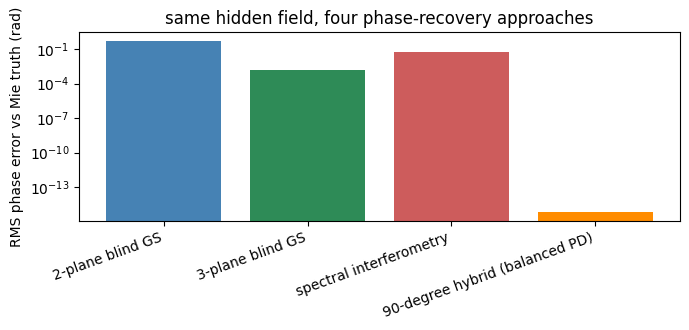

In [5]:
df_compare = pd.DataFrame([
    {"method": "2-plane blind GS", "needs_LO": False, "rms_vs_truth_rad": demo_2plane['rms_gs_vs_truth']},
    {"method": "3-plane blind GS", "needs_LO": False, "rms_vs_truth_rad": demo_3plane['rms_vs_truth']},
    {"method": "spectral interferometry", "needs_LO": "reference arm", "rms_vs_truth_rad": rms_si},
    {"method": "90-degree hybrid (balanced PD)", "needs_LO": True, "rms_vs_truth_rad": rms_hybrid},
])
display(df_compare)

plt.figure(figsize=(7, 3.4))
plt.bar(df_compare['method'], df_compare['rms_vs_truth_rad'],
        color=['steelblue', 'seagreen', 'indianred', 'darkorange'])
plt.yscale('log'); plt.ylabel('RMS phase error vs Mie truth (rad)')
plt.xticks(rotation=20, ha='right')
plt.title('same hidden field, four phase-recovery approaches')
plt.tight_layout(); plt.show()

## Summary

| Method | Needs a local oscillator? | Hardware |
|---|---|---|
| 2-/3-plane blind GS | No | two or more known dispersions only |
| Spectral interferometry | Reference arm (interferometric) | delayed copy of the signal itself |
| 90-degree hybrid | **Yes, an actual LO laser** | the real, standard telecom coherent-receiver component |

The founding brief's whole premise -- phase from intensity alone, no local
oscillator -- exists specifically to avoid needing the third row of this
table. The 90-degree hybrid is now a real, tested, bug-fixed piece of this
repo (`projects/vpi_hybrid90deg/`), not a competitor to blind GS but the
concrete illustration of what hardware the "carrier-less receiver" premise
was written to eliminate.